In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

In [2]:
# Access to regional shapes
shapes = '/glade/campaign/acom/MUSICA/emis/htap3/regional_mask_0.1deg.nc'
ds = xr.open_dataset(shapes)

BNA = ds.region_mask.sel(region = 'BNA') # Boreal North America
TNA = ds.region_mask.sel(region = 'TNA') # Temperate North America
ANZ = ds.region_mask.sel(region = 'ANZ') # Australia and New Zealand

In [6]:
# Time series plotting
def timeseries(file, lat_lims, lon_lims, method, start, end, aerosol):
    '''
    Plots time series of selected pollutant over desired latitude/longitude range and time range using chosen aggregation method. Plots each time series in its own figure window.
    Takes arguments (file='path_to_file', lat_lims=[left=value, right=value], lon_lims=[left=value, right=value], method='mean'/'sum'/'median', start='YYYY-MM-DD' (datetime form of desired start time), 
    end='YYYY-MM-DD' (datetime form of desired end time), aerosol='aerosol_name'). Meant to read in netcdf files of emissions from CESM2.2 model runs. Files should have latitude, longitude, and time coordinates.
    '''
    if lat_lims[0] >= lat_lims[1]:
        raise ValueError('First latitude input must be smaller than the second.')

    if lon_lims[0] >= lon_lims[1]:
        raise ValueError('First longitude input must be smaller than the second.')
        
    ds = xr.open_dataset(file)
    area = ds.sel(lat=slice(lat_lims[0], lat_lims[1]))
    area = area.sel(lon=slice(lon_lims[0], lon_lims[1]))
    
    if method == 'mean':
        sub = area.mean(dim='lat')
        result = sub.mean(dim='lon')
    elif method == 'sum':
        sub = area.sum(dim='lat')
        result = sub.sum(dim='lon')
    elif method == 'median':
        sub = area.median(dim='lat')
        result = sub.median(dim='lon')
    else:
        raise ValueError('Not a supported aggregation method. Choose either mean, median, or sum.')
        
    result = result.drop_vars('date')
    values = result.sel(time=slice(start, end))
    values_arr = values.to_dataarray()
    
    fig = plt.figure()
    ax = plt.axes()
    values_arr.plot() 
    method = method.capitalize()
    aerosol = aerosol.capitalize()
    plt.title(f'{method} {aerosol} from {lat_lims[0]}-{lat_lims[1]} Degrees North and {lon_lims[0]}-{lon_lims[1]} Degrees East Over Time')
    ax.set_xlabel('Time')
    ax.set_ylabel(f'{aerosol} Emission Flux (kgm⁻²s⁻¹)')
    return None


In [15]:
# Plot multiple time series on a single plot
def timeseries_compare(files, lat_lims, lon_lims, method, start, end, aerosols):
    '''Plots time series of multiple pollutants over a selected lat/lon range and tine range on a single plot. Takes arguments (files=iterable_coll_of_files, lat_lims=[left=value, right=value],
       lon_lims=[left=value, right=value], method='mean'/'sum'/'median', start='YYYY-MM-DD' (datetime form of desired start time), end='YYYY-MM-DD' (datetime form of desired end time),
       aerosols=iterable_of_aerosol_names). Meant to read in netcdf files of emissions from CESM2.2 model runs. Files should have latitude, longitude, and time coordinates. '''
    
    # Error handling
    if len(files) == len(aerosols):
        pass
    else:
        raise ValueError('Number of data files and aerosol names must be equal.')

    if lat_lims[0] >= lat_lims[1]:
        raise ValueError('First latitude input must be smaller than the second.')

    if lon_lims[0] >= lon_lims[1]:
        raise ValueError('First longitude input must be smaller than the second.')
        
    for i in range(len(aerosols)):
        aerosols[i] = (aerosols[i]).capitalize()
    method = method.capitalize()
    fig = plt.figure()
    ax = plt.axes()

    lines = []
    
    for f in files:
        ds = xr.open_dataset(f)
        area = ds.sel(lat=slice(lat_lims[0], lat_lims[1]))
        area = area.sel(lon=slice(lon_lims[0], lon_lims[1]))
    
        if method == 'Mean':
            sub = area.mean(dim='lat')
            result = sub.mean(dim='lon')
        elif method == 'Sum':
            sub = area.sum(dim='lat')
            result = sub.sum(dim='lon')
        elif method == 'Median':
            sub = area.median(dim='lat')
            result = sub.median(dim='lon')
        else:
            raise ValueError('Not a supported aggregation method. Choose either mean, median, or sum.')
        
        result = result.drop_vars('date')
        values = result.sel(time=slice(start, end))
        values_arr = values.to_dataarray()
        val = values_arr.plot()
        lines.append(val[0])

        
    ax.set_xlabel('Time')
    ax.set_ylabel('Emission Flux (kgm⁻²s⁻¹)')
    plt.title(f'{method} of {', '.join(a for a in aerosols)} from {lat_lims[0]}-{lat_lims[1]} Degrees North and {lon_lims[0]}-{lon_lims[1]} Degrees East Over Time')
    plt.legend(lines, aerosols)
    return None

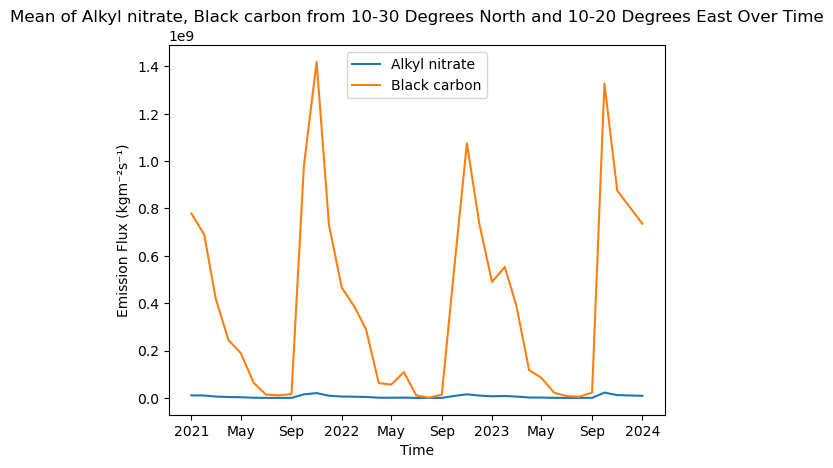

In [16]:
files=['/glade/work/ekeefe/research_code/gfas4htap_fire_emissions/gfas4htap-moz_ALKNIT_bb_2003-2023_f09_c20260306.nc', '/glade/work/ekeefe/research_code/gfas4htap_fire_emissions/gfas4htap-moz_bc_a4_bb_2003-2023_f09_c20260306.nc']
aerosols=['alkyl nitrate', 'black carbon']

timeseries_compare(files, [10,30], [10,20], 'mean', start='2021-01-01', end='2024-01-01', aerosols=aerosols)